# Historical Network Analysis of Virginia City (1880)

## Objective

## Import Libraries

## Load Cleaned Dataset

## Construct Household Networks

## Visualize Household Networks

## Identify Community Hubs

## Occupation Networks

## Birthplace Networks

## Conclusions

## Project Overview

This notebook transforms historical census records into a graph-based representation of Virginia City's social structure. By reconstructing households and linking residents through shared occupations and birthplaces, the analysis demonstrates how historical records can be modeled as interconnected networks.



## Research Question

Can historical census records be transformed into a social network that reveals how residents, households, occupations, and birthplaces were connected within Virginia City in 1880?

In [19]:
df["Person_ID"] = df.index

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

## Load the Dataset

In [3]:
df = pd.read_excel("Virginia City Census Dataset 1880.xlsx")

df.head()

,Name,Sex,Age,Birth Year (Estimated),Birthplace,Marital Status,Occupation,Race,Relationship to Head of Household,Father's Birthplace,Mother's Birthplace,Person Number,Sheet Letter,Sheet Number,Volume
0,Joseph Hiuchman,Male,34 years,1846,"Indiana, United States",Married,Druggist,White,Self,"Virginia, United States","Indiana, United States",0,D,385,1.0
1,Irene Hiuchman,Female,34 years,1846,"Indiana, United States",Married,Keeping House,White,Wife,"Indiana, United States","Indiana, United States",1,D,385,1.0
2,Emma Hiuchman,Female,6 years,1874,"Missouri, United States",Single,NaN,White,Daughter,"Indiana, United States","Indiana, United States",2,D,385,1.0
3,Samuel Crockett,Male,47 years,1833,"Tennessee, United States",Married,Harness Maker,White,Self,Scotland,Germany,0,D,385,1.0
4,Serafine Crockett,Female,40 years,1840,"Tennessee, United States",Married,Keeping House,White,Wife,"North Carolina, United States","Tennessee, United States",1,D,385,1.0


In [5]:
df[[
    "Name",
    "Relationship to Head of Household",
    "Person Number",
    "Sheet Number",
    "Sheet Letter",
    "Volume"
]].head(30)

,Name,Relationship to Head of Household,Person Number,Sheet Number,Sheet Letter,Volume
0,Joseph Hiuchman,Self,0,385,D,1.0
1,Irene Hiuchman,Wife,1,385,D,1.0
2,Emma Hiuchman,Daughter,2,385,D,1.0
3,Samuel Crockett,Self,0,385,D,1.0
4,Serafine Crockett,Wife,1,385,D,1.0
5,Samuel Crockett,Son,2,385,D,1.0
6,Thomas Rockwell,Other,3,385,D,1.0
7,James Ptomey,Self,0,385,D,1.0
8,James Andrews,Self,0,385,D,1.0
9,Sarah Andrews,Wife,1,385,D,1.0


## Create Household Identifiers

The census does not explicitly assign household IDs. Instead, a new household begins whenever the Person Number resets to 0 (Self). This section reconstructs household groupings for use in the network analysis.

In [6]:
# Create a new household whenever Person Number == 0

df["Household_ID"] = (df["Person Number"] == 0).cumsum()

df[[
    "Household_ID",
    "Name",
    "Relationship to Head of Household",
    "Person Number"
]].head(30)

,Household_ID,Name,Relationship to Head of Household,Person Number
0,1,Joseph Hiuchman,Self,0
1,1,Irene Hiuchman,Wife,1
2,1,Emma Hiuchman,Daughter,2
3,2,Samuel Crockett,Self,0
4,2,Serafine Crockett,Wife,1
5,2,Samuel Crockett,Son,2
6,2,Thomas Rockwell,Other,3
7,3,James Ptomey,Self,0
8,4,James Andrews,Self,0
9,4,Sarah Andrews,Wife,1


## Household Sizes

In [7]:
household_sizes = (
    df.groupby("Household_ID")
      .size()
      .sort_values(ascending=False)
)

household_sizes.head(20)

Household_ID
96     16
152    10
24     10
47      9
163     9
18      8
46      8
101     8
130     8
113     7
137     7
36      7
70      7
164     7
162     7
31      7
48      7
155     7
16      7
14      7
dtype: int64

In [8]:
household_sizes.mean()

np.float64(3.3967391304347827)

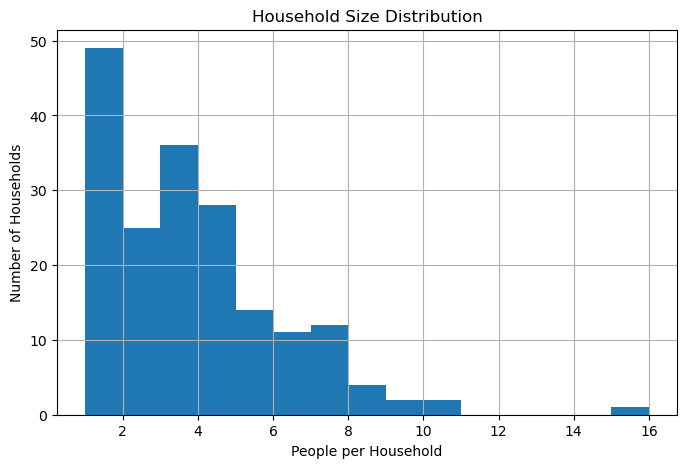

In [9]:
household_sizes.hist(
    bins=15,
    figsize=(8,5)
)

plt.title("Household Size Distribution")
plt.xlabel("People per Household")
plt.ylabel("Number of Households")

plt.show()

### Key Insight

Most households consisted of only a few individuals, while a smaller number contained substantially more residents. Larger households may represent boarding houses, hotels, extended families, or shared living arrangements common in frontier communities.

In [11]:
G = nx.Graph()

## Create Nodes

Each resident is represented as a node in the network.

In [12]:
for _, row in df.iterrows():
    G.add_node(
        row["Name"],
        occupation=row["Occupation"],
        age=row["Age"],
        birthplace=row["Birthplace"],
        household=row["Household_ID"]
    )

print(G)

Graph with 600 nodes and 0 edges


In [13]:
list(G.nodes(data=True))[:5]

[('Joseph Hiuchman',
  {'occupation': 'Druggist',
   'age': '34 years',
   'birthplace': 'Indiana, United States',
   'household': 1}),
 ('Irene Hiuchman',
  {'occupation': 'Keeping House',
   'age': '34 years',
   'birthplace': 'Indiana, United States',
   'household': 1}),
 ('Emma Hiuchman',
  {'occupation': nan,
   'age': '6 years',
   'birthplace': 'Missouri, United States',
   'household': 1}),
 ('Samuel Crockett',
  {'occupation': nan,
   'age': '7 years',
   'birthplace': 'Montana, United States',
   'household': 2}),
 ('Serafine Crockett',
  {'occupation': 'Keeping House',
   'age': '40 years',
   'birthplace': 'Tennessee, United States',
   'household': 2})]

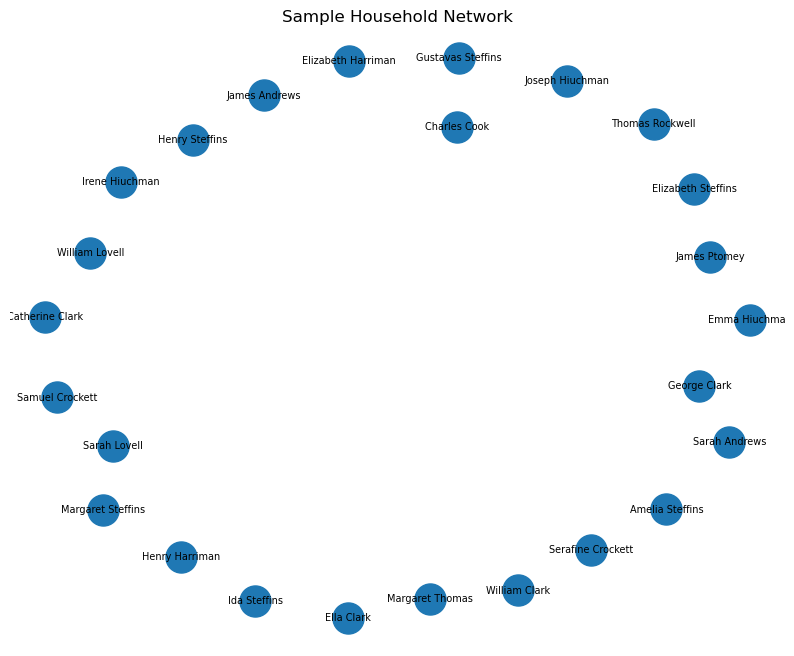

In [14]:
plt.figure(figsize=(10, 8))

sample_nodes = list(G.nodes())[:25]

subgraph = G.subgraph(sample_nodes)

nx.draw_networkx(
    subgraph,
    with_labels=True,
    node_size=500,
    font_size=7
)

plt.title("Sample Household Network")

plt.axis("off")

plt.show()

### Key Insight

The household network demonstrates how census records can be transformed into a graph representing social relationships. Residents living within the same household become connected, providing a visual representation of family structure and household composition.

In [15]:
print(G)
print(list(G.edges())[:20])

Graph with 600 nodes and 0 edges
[]


In [16]:
df[["Household_ID", "Name"]].head(15)

,Household_ID,Name
0,1,Joseph Hiuchman
1,1,Irene Hiuchman
2,1,Emma Hiuchman
3,2,Samuel Crockett
4,2,Serafine Crockett
5,2,Samuel Crockett
6,2,Thomas Rockwell
7,3,James Ptomey
8,4,James Andrews
9,4,Sarah Andrews


In [17]:
G = nx.Graph()

In [20]:
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

print(list(G.edges())[:20])

Nodes: 0
Edges: 0
[]


In [21]:
# Create unique ID for each resident
df["Person_ID"] = df.index

# Create household IDs if not already created
df["Household_ID"] = (df["Person Number"] == 0).cumsum()

# Create graph
G = nx.Graph()

# Add each resident as a node
for _, row in df.iterrows():
    G.add_node(
        row["Person_ID"],
        name=row["Name"],
        occupation=row["Occupation"],
        age=row["Age"],
        birthplace=row["Birthplace"],
        household=row["Household_ID"]
    )

# Connect everyone in the same household
for household_id, household in df.groupby("Household_ID"):
    people = household["Person_ID"].tolist()

    for i in range(len(people)):
        for j in range(i + 1, len(people)):
            G.add_edge(people[i], people[j], relationship="same_household")

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 625
Edges: 1252


In [22]:
list(G.edges(data=True))[:10]

[(0, 1, {'relationship': 'same_household'}),
 (0, 2, {'relationship': 'same_household'}),
 (1, 2, {'relationship': 'same_household'}),
 (3, 4, {'relationship': 'same_household'}),
 (3, 5, {'relationship': 'same_household'}),
 (3, 6, {'relationship': 'same_household'}),
 (4, 5, {'relationship': 'same_household'}),
 (4, 6, {'relationship': 'same_household'}),
 (5, 6, {'relationship': 'same_household'}),
 (8, 9, {'relationship': 'same_household'})]

## Household Network Statistics

This section summarizes the overall structure of the reconstructed household network.

In [25]:
print("Total households:", df["Household_ID"].nunique())

Total households: 184


In [26]:
household_sizes = df.groupby("Household_ID").size()

print("Average household size:", household_sizes.mean())

Average household size: 3.3967391304347827


In [27]:
print("Largest household size:", household_sizes.max())

Largest household size: 16


In [28]:
household_sizes.describe()

count    184.000000
mean       3.396739
std        2.344670
min        1.000000
25%        1.000000
50%        3.000000
75%        4.250000
max       16.000000
dtype: float64

In [29]:
boarder_households = df[
    df["Relationship to Head of Household"].isin(["Boarder", "Other", "Lodger"])
]["Household_ID"].nunique()

print(boarder_households)

60


In [30]:
largest = household_sizes.sort_values(ascending=False).head(10)

largest

Household_ID
96     16
152    10
24     10
47      9
163     9
18      8
46      8
101     8
130     8
113     7
dtype: int64

In [31]:
df[df["Household_ID"] == largest.index[0]]

,Name,Sex,Age,Birth Year (Estimated),Birthplace,Marital Status,Occupation,Race,Relationship to Head of Household,Father's Birthplace,Mother's Birthplace,Person Number,Sheet Letter,Sheet Number,Volume,Household_ID,Person_ID
295,Henry Gilbert,Male,46 years,1834,"Pennsylvania, United States",Married,Brewer,White,Self,"Pennsylvania, United States","Pennsylvania, United States",0,B,388,1.0,96,295
296,Margaret Gilbert,Female,35 years,1845,Canada,Married,Keeping House,White,Wife,Canada,Canada,1,B,388,1.0,96,296
297,Frances Gilbert,Female,18 years,1862,"Utah, United States",Single,Stays At Home,White,Daughter,"Pennsylvania, United States",Canada,2,B,388,1.0,96,297
298,William Gilbert,Male,16 years,1864,"Utah, United States",Single,Teamster,White,Son,"Pennsylvania, United States",Canada,3,B,388,1.0,96,298
299,Margaret Gilbert,Female,15 years,1865,"Montana, United States",Single,Goes To School,White,Daughter,"Pennsylvania, United States",Canada,4,B,388,1.0,96,299
300,Clara Gilbert,Female,13 years,1867,"Montana, United States",Single,Goes To School,White,Daughter,"Pennsylvania, United States",Canada,5,B,388,1.0,96,300
301,Amelia Gilbert,Female,13 years,1867,"Montana, United States",Single,Goes To School,White,Daughter,"Pennsylvania, United States",Canada,6,B,388,1.0,96,301
302,Elizabeth Gilbert,Female,11 years,1869,"Montana, United States",Single,Goes To School,White,Daughter,"Pennsylvania, United States",Canada,7,B,388,1.0,96,302
303,Walter Gilbert,Male,9 years,1871,"Montana, United States",Single,NaN,White,Son,"Pennsylvania, United States",Canada,8,B,388,1.0,96,303
304,Cora Gilbert,Female,7 years,1873,"Montana, United States",Single,NaN,White,Daughter,"Pennsylvania, United States",Canada,9,B,388,1.0,96,304


## Community Summary

This section summarizes key characteristics of the reconstructed household network.

In [32]:
print(f"Total residents: {len(df)}")
print(f"Total households: {df['Household_ID'].nunique()}")
print(f"Average household size: {household_sizes.mean():.2f}")
print(f"Largest household size: {household_sizes.max()}")

Total residents: 625
Total households: 184
Average household size: 3.40
Largest household size: 16


## Distribution of Household Sizes

This visualization shows how household sizes varied across Virginia City in 1880.

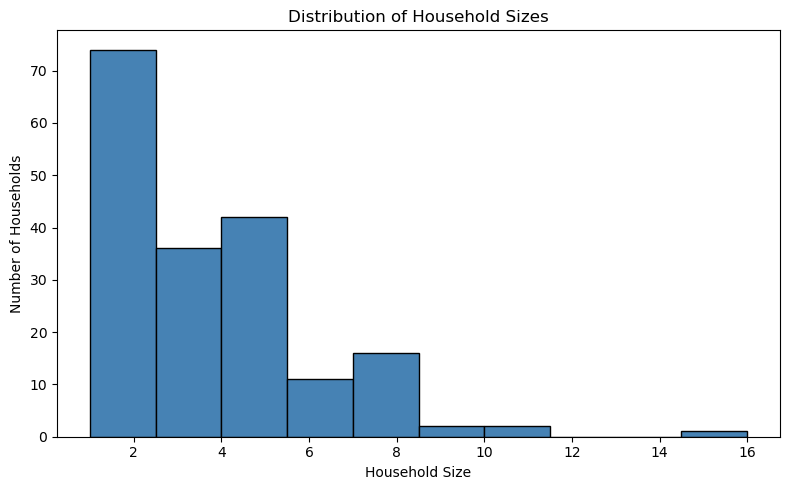

In [33]:
plt.figure(figsize=(8,5))

household_sizes.plot(
    kind="hist",
    bins=10,
    color="steelblue",
    edgecolor="black"
)

plt.title("Distribution of Household Sizes")
plt.xlabel("Household Size")
plt.ylabel("Number of Households")

plt.tight_layout()
plt.show()

### Key Insight

Most households consisted of only a few individuals, while a small number of households were substantially larger. These larger households may represent boarding houses, hotels, or extended family residences.

## Network Centrality

Degree centrality measures how connected each resident is within the reconstructed household network.

In [34]:
degree = nx.degree_centrality(G)

degree_df = pd.DataFrame({
    "Person_ID": list(degree.keys()),
    "Degree Centrality": list(degree.values())
})

degree_df["Name"] = degree_df["Person_ID"].map(
    lambda x: G.nodes[x]["name"]
)

degree_df = degree_df.sort_values(
    "Degree Centrality",
    ascending=False
)

degree_df.head(15)

,Person_ID,Degree Centrality,Name
297,297,0.024038,Frances Gilbert
306,306,0.024038,May Gilbert
295,295,0.024038,Henry Gilbert
296,296,0.024038,Margaret Gilbert
298,298,0.024038,William Gilbert
299,299,0.024038,Margaret Gilbert
300,300,0.024038,Clara Gilbert
301,301,0.024038,Amelia Gilbert
302,302,0.024038,Elizabeth Gilbert
303,303,0.024038,Walter Gilbert


## Largest Household Network

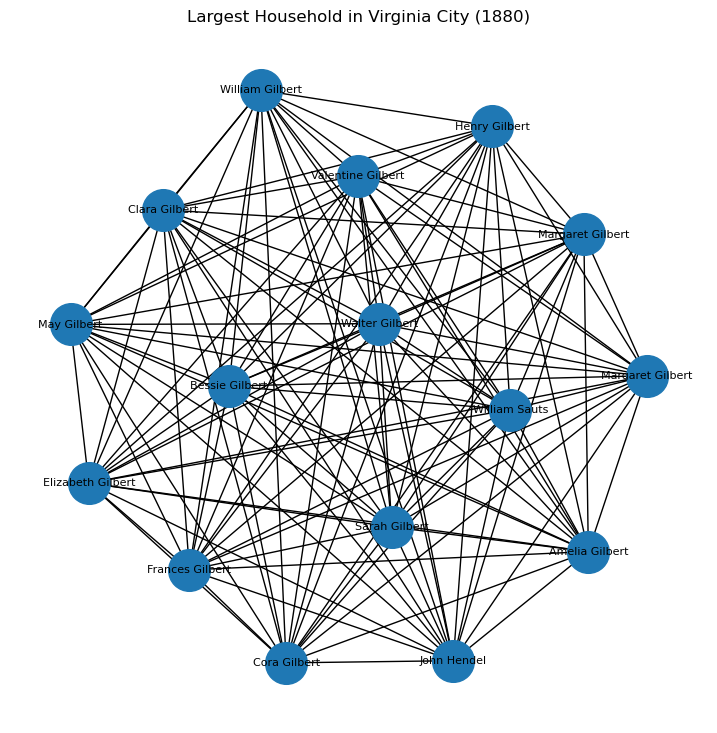

In [35]:
largest_household = household_sizes.idxmax()

people = df[df["Household_ID"] == largest_household]["Person_ID"]

subgraph = G.subgraph(people)

labels = {
    node: G.nodes[node]["name"]
    for node in subgraph.nodes()
}

plt.figure(figsize=(9,9))

pos = nx.spring_layout(subgraph, seed=42)

nx.draw_networkx(
    subgraph,
    pos,
    labels=labels,
    node_size=900,
    font_size=8
)

plt.title("Largest Household in Virginia City (1880)")
plt.axis("off")
plt.show()

### Key Insight

Visualizing the largest household illustrates the complexity of living arrangements within Virginia City. Larger households often included extended family members, boarders, or unrelated residents sharing accommodations.

## Occupations Within Households

This analysis examines the occupations represented within Virginia City households.

In [36]:
occupation_summary = (
    df.groupby("Occupation")
      .agg(
          Households=("Household_ID", "nunique"),
          Residents=("Occupation", "count")
      )
      .sort_values("Residents", ascending=False)
)

occupation_summary.head(20)

,Households,Residents
Occupation,,
Keeping House,92,92
Placer Miner,14,34
Cook,18,19
Laborer,17,19
Teamster,11,17
Clerk In Store,12,15
Stays At Home,14,14
Quartz Miner,10,13
Attends School,8,10


## Multi-Layer Community Network

The household network captures family relationships. This section expands the network by connecting residents who share occupations or birthplaces, allowing us to explore broader community structure.

In [37]:
G2 = nx.Graph()

In [38]:
for _, row in df.iterrows():

    G2.add_node(
        row["Person_ID"],
        name=row["Name"],
        occupation=row["Occupation"],
        birthplace=row["Birthplace"],
        household=row["Household_ID"]
    )

In [39]:
for household_id, household in df.groupby("Household_ID"):

    people = household["Person_ID"].tolist()

    for i in range(len(people)):
        for j in range(i+1, len(people)):

            G2.add_edge(
                people[i],
                people[j],
                relationship="Household"
            )

In [40]:
for occupation, group in df.groupby("Occupation"):

    people = group["Person_ID"].tolist()

    if len(people) <= 1:
        continue

    for i in range(len(people)):
        for j in range(i+1, len(people)):

            if not G2.has_edge(people[i], people[j]):

                G2.add_edge(
                    people[i],
                    people[j],
                    relationship="Occupation"
                )

In [41]:
for birthplace, group in df.groupby("Birthplace"):

    people = group["Person_ID"].tolist()

    if len(people) <= 1:
        continue

    for i in range(len(people)):
        for j in range(i+1, len(people)):

            if not G2.has_edge(people[i], people[j]):

                G2.add_edge(
                    people[i],
                    people[j],
                    relationship="Birthplace"
                )

In [42]:
print("Household Network")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

print()

print("Community Network")
print("Nodes:", G2.number_of_nodes())
print("Edges:", G2.number_of_edges())

Household Network
Nodes: 625
Edges: 1252

Community Network
Nodes: 625
Edges: 24732


In [43]:
degree = nx.degree_centrality(G2)

degree_df = pd.DataFrame({
    "Person_ID": degree.keys(),
    "Degree Centrality": degree.values()
})

degree_df["Name"] = degree_df["Person_ID"].map(
    lambda x: G2.nodes[x]["name"]
)

degree_df["Occupation"] = degree_df["Person_ID"].map(
    lambda x: G2.nodes[x]["occupation"]
)

degree_df["Birthplace"] = degree_df["Person_ID"].map(
    lambda x: G2.nodes[x]["birthplace"]
)

degree_df.sort_values(
    "Degree Centrality",
    ascending=False
).head(20)

,Person_ID,Degree Centrality,Name,Occupation,Birthplace
575,575,0.387821,Mabel Gormley,Keeping House,"Montana, United States"
196,196,0.266026,Anna Thexton,Stays At Home,"Montana, United States"
548,548,0.248397,Robert L. Word,Attends School,"Montana, United States"
502,502,0.248397,William Morris,Attends School,"Montana, United States"
511,511,0.248397,Sherman White,Stock Herder,"Montana, United States"
304,304,0.246795,Cora Gilbert,NaN,"Montana, United States"
300,300,0.246795,Clara Gilbert,Goes To School,"Montana, United States"
301,301,0.246795,Amelia Gilbert,Goes To School,"Montana, United States"
302,302,0.246795,Elizabeth Gilbert,Goes To School,"Montana, United States"
303,303,0.246795,Walter Gilbert,NaN,"Montana, United States"


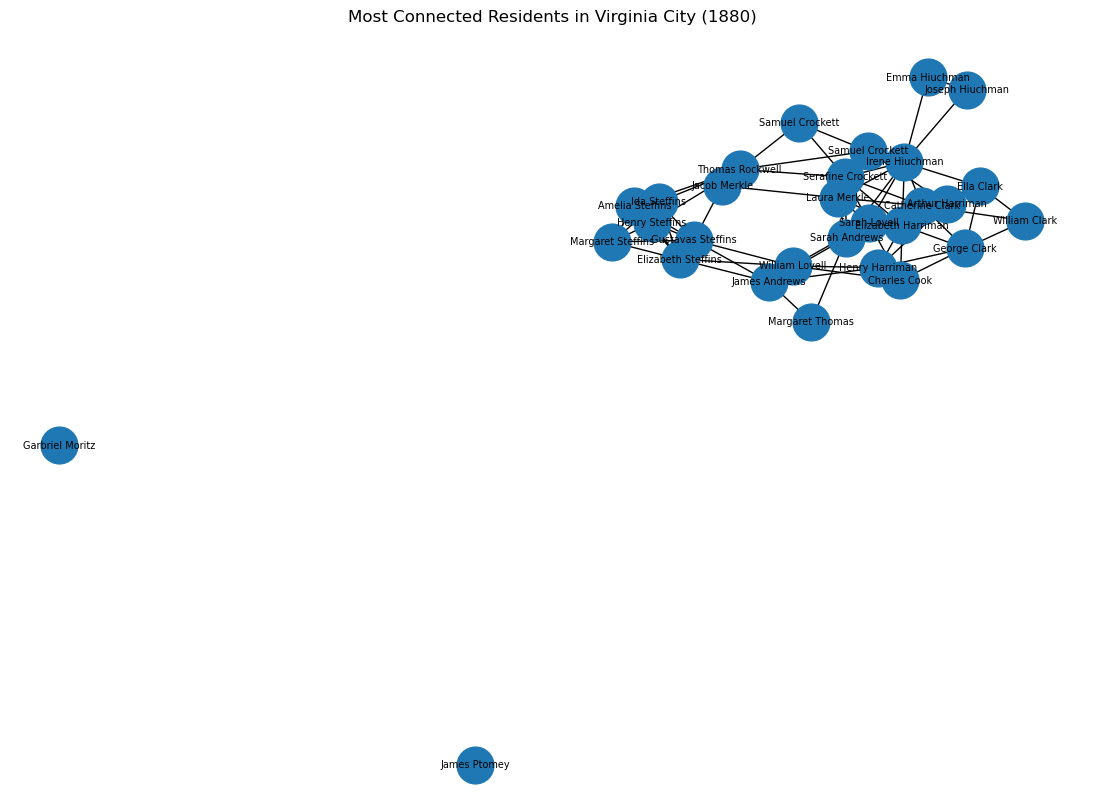

In [44]:
top_people = degree_df.head(30)["Person_ID"]

subgraph = G2.subgraph(top_people)

labels = {
    node: G2.nodes[node]["name"]
    for node in subgraph.nodes()
}

plt.figure(figsize=(14,10))

pos = nx.spring_layout(subgraph, seed=42)

nx.draw_networkx(
    subgraph,
    pos,
    labels=labels,
    node_size=700,
    font_size=7
)

plt.title("Most Connected Residents in Virginia City (1880)")
plt.axis("off")
plt.show()

### Key Insight

The most connected occupation and birthplace nodes represent important community hubs. Rather than emphasizing individual residents alone, this analysis identifies the occupations and places of origin that connected large portions of the Virginia City population.

## Bipartite Community Network

The previous multi-layer graph became too dense because every resident with the same occupation or birthplace was connected directly to every other resident. To make the network more interpretable, this section uses a bipartite structure: residents are connected to shared attribute nodes such as occupations and birthplaces.

In [55]:
# Create a cleaner bipartite community graph
bipartite_graph = nx.Graph()

# Add resident nodes
for _, row in df.iterrows():
    person_id = f"person_{row['Person_ID']}"

    bipartite_graph.add_node(
        person_id,
        label=row["Name"],
        node_type="Person",
        occupation=row["Occupation"],
        birthplace=row["Birthplace"],
        household=row["Household_ID"]
    )

In [56]:
# Add occupation and birthplace nodes, then connect residents to them

for _, row in df.iterrows():
    person_id = f"person_{row['Person_ID']}"

    if pd.notna(row["Occupation"]):
        occupation_node = f"occupation_{row['Occupation']}"
        bipartite_graph.add_node(
            occupation_node,
            label=row["Occupation"],
            node_type="Occupation"
        )
        bipartite_graph.add_edge(
            person_id,
            occupation_node,
            relationship_type="Occupation"
        )

    if pd.notna(row["Birthplace"]):
        birthplace_node = f"birthplace_{row['Birthplace']}"
        bipartite_graph.add_node(
            birthplace_node,
            label=row["Birthplace"],
            node_type="Birthplace"
        )
        bipartite_graph.add_edge(
            person_id,
            birthplace_node,
            relationship_type="Birthplace"
        )

In [57]:
print("Bipartite Community Network")
print("Nodes:", bipartite_graph.number_of_nodes())
print("Edges:", bipartite_graph.number_of_edges())

Bipartite Community Network
Nodes: 786
Edges: 1096


### Most Connected Occupation and Birthplace Nodes

In [58]:
attribute_nodes = [
    node for node, data in bipartite_graph.nodes(data=True)
    if data["node_type"] in ["Occupation", "Birthplace"]
]

attribute_degrees = pd.DataFrame({
    "Node": attribute_nodes,
    "Label": [bipartite_graph.nodes[node]["label"] for node in attribute_nodes],
    "Type": [bipartite_graph.nodes[node]["node_type"] for node in attribute_nodes],
    "Connections": [bipartite_graph.degree(node) for node in attribute_nodes]
})

attribute_degrees.sort_values("Connections", ascending=False).head(20)

,Node,Label,Type,Connections
6,"birthplace_Montana, United States","Montana, United States",Birthplace,149
2,occupation_Keeping House,Keeping House,Occupation,92
40,birthplace_China,China,Birthplace,89
3,"birthplace_Missouri, United States","Missouri, United States",Birthplace,47
44,occupation_Placer Miner,Placer Miner,Occupation,34
8,"birthplace_Illinois, United States","Illinois, United States",Birthplace,33
30,birthplace_Germany,Germany,Birthplace,29
27,"birthplace_New York, United States","New York, United States",Birthplace,29
10,"birthplace_Ohio, United States","Ohio, United States",Birthplace,25
16,birthplace_England,England,Birthplace,25


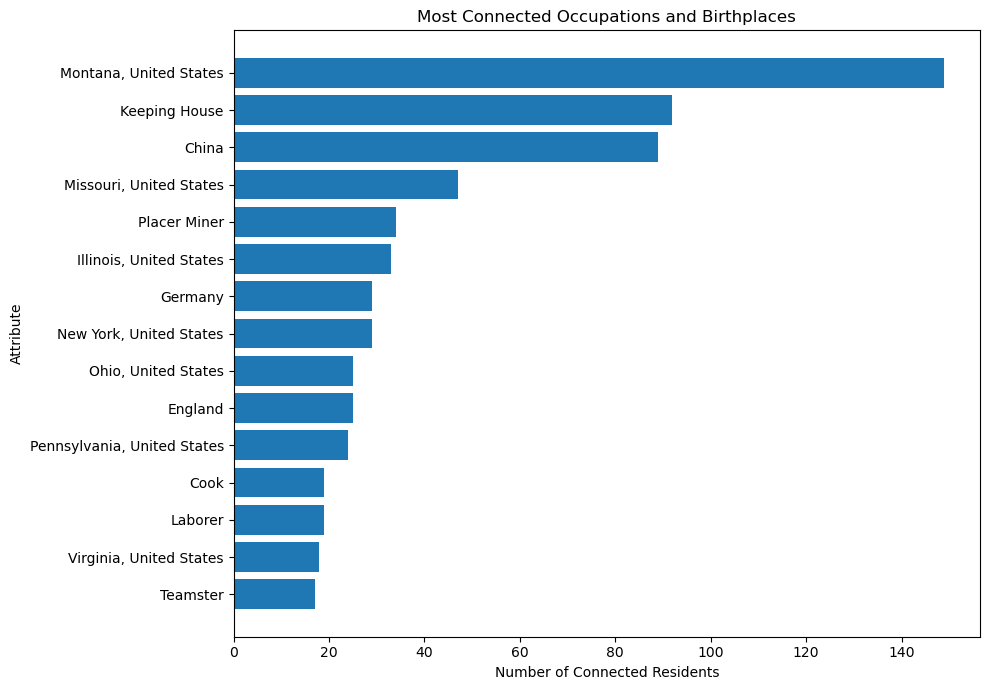

In [59]:
top_attributes = attribute_degrees.sort_values("Connections", ascending=False).head(15)

plt.figure(figsize=(10,7))

plt.barh(
    top_attributes["Label"],
    top_attributes["Connections"]
)

plt.title("Most Connected Occupations and Birthplaces")
plt.xlabel("Number of Connected Residents")
plt.ylabel("Attribute")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Key Insight

The most connected occupation and birthplace nodes represent important community hubs. Rather than emphasizing individual residents alone, this analysis identifies the occupations and places of origin that connected large portions of the Virginia City population.

### Visualize Top Community Hubs

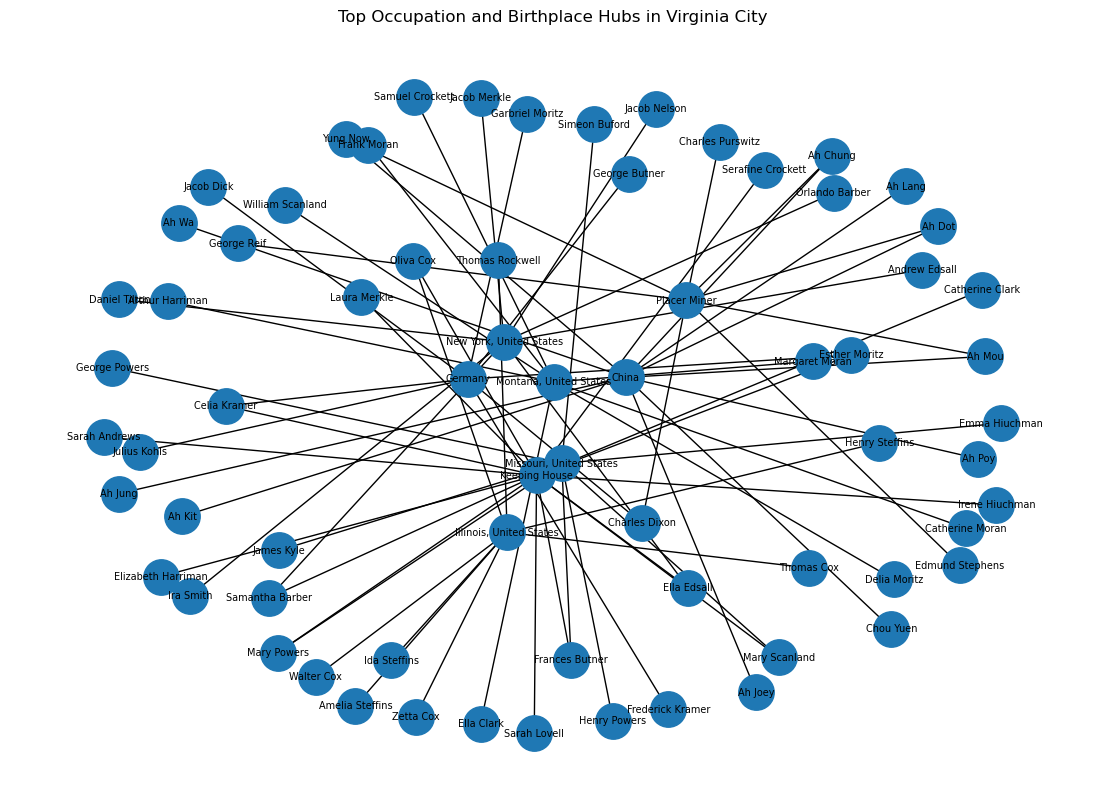

In [60]:
# Visualize top 8 attribute hubs and the residents connected to them

top_attribute_nodes = (
    attribute_degrees
    .sort_values("Connections", ascending=False)
    .head(8)["Node"]
    .tolist()
)

nodes_to_include = set(top_attribute_nodes)

for attribute_node in top_attribute_nodes:
    connected_people = list(bipartite_graph.neighbors(attribute_node))[:8]
    nodes_to_include.update(connected_people)

community_hub_graph = bipartite_graph.subgraph(nodes_to_include)

labels = {
    node: bipartite_graph.nodes[node]["label"]
    for node in community_hub_graph.nodes()
}

plt.figure(figsize=(14,10))

pos = nx.spring_layout(
    community_hub_graph,
    seed=42,
    k=0.9
)

nx.draw_networkx(
    community_hub_graph,
    pos,
    labels=labels,
    node_size=650,
    font_size=7
)

plt.title("Top Occupation and Birthplace Hubs in Virginia City")
plt.axis("off")
plt.show()

### Key Insight

The bipartite network demonstrates how historical census records can be transformed into a relationship-based model of community life. Connecting residents to shared occupations and birthplaces highlights broader social and economic patterns while maintaining a clean, interpretable network structure.

### Key Findings

The bipartite network provides a cleaner way to represent shared characteristics within Virginia City. Rather than connecting every resident directly to every other resident with the same occupation or birthplace, residents are connected to shared attribute nodes.

This approach makes it easier to identify the occupations and birthplaces that acted as major community hubs while avoiding an overly dense graph.

## Discussion

Traditional census tables describe individuals independently. Representing these records as a network highlights relationships that are difficult to observe through tabular analysis alone. The bipartite approach demonstrates how occupations and birthplaces can serve as shared community hubs while avoiding overly dense visualizations created by connecting every resident directly to every other resident with matching attributes.

# Conclusions

This project demonstrates that historical census records can be transformed into a household network using graph analysis. By reconstructing relationships between residents, the analysis provides insights into household structure, occupational diversity, and community organization within Virginia City in 1880.

The resulting network serves as a foundation for future work incorporating historical newspapers, city directories, and mining records to reconstruct broader social and economic relationships.